# CRISP-DM: Entendimiento del negocio y Entendimiento de los datos

## Descarga de datos

Los datos fueron tomados del portal de datos abiertos de Colombia.

Los datos que se van a analizar en este documento, son los de [Tarifas aplicadas de Gas Natural](https://www.datos.gov.co/Minas-y-Energ-a/Tarifas-aplicadas-de-Gas-Natural/ek3f-5wn4/about_data), donde se presenta información reportada por las empresas distribuidoras de gas natural, reguladas por la CREG.

### Descripcion de los datos

El conjunto de datos cuenta con 14 columnas, que se describen a continuacion:


| Nombre de la columna | Descripción | Nombre del campo API | Tipo de Dato |
| :--- | :--- | :--- | :--- |
| ANO | ano | ano | Texto |
| MES | mes | mes | Número |
| EMPRESA | Nombre de la empresa prestadora del servicio de Gas Natural | empresa | Texto |
| MUNICIPIOS | Municipios del mercado relevante de Gas Natural | municipios | Texto |
| NIT | Número de identificación tributaria | nit | Texto |
| ID MERCADO | Código de un grupo de municipios que se definen por Resolución CREG | id_mercado | Número |
| ID_EMPRESA | Código asignado al prestador de Gas Natural asignado por el SUI administrado por la Superintencia de Servicios Públicos SSPD | id_empresa | Número |
| ESTRATO | Estrato socio-economico residencial de los usuarios de Gas Natural | estrato | Número |
| CONEXION | Valor (cantidad monetaria) de conexión del servicio de Gas Natural para un usuario, según su estrato | conexion | Número |
| REINSTALACION | Valor (cantidad monetaria) de reinstalacion del servicio de Gas Natural para un usuario, según su estrato | reinstalacion | Número |
| RECONEXION | Valor (cantidad monetaria) de reconexion del servicio de Gas Natural para un usuario, según su estrato | reconexion | Texto |
| CARGO_FIJO | Valor (cantidad monetaria) de la tarifa fija del servicio de Gas Natural para un usuario, según su estrato | cargo_fijo | Número |
| RANGO_0 | Valor (cantidad monetaria) del pago servicio de Gas Natural para un usuario, según su estrato y su consumo (si es menor a 20M^3) | rango_0 | Número |
| RANGO_21 | Valor (cantidad monetaria) del pago servicio de Gas Natural para un usuario, según su estrato y su consumo (si es mayor a 20M^3) | rango_21 | Número |




In [1]:
# Importacion de librerias
import pandas as pd
import matplotlib.pyplot as plt
from unidecode import unidecode

In [2]:
df = pd.read_csv("archivos/Tarifas_aplicadas_de_Gas_Natural_20260124.csv", thousands=",", decimal=".")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 165360 entries, 0 to 165359
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   ANO            165360 non-null  int64  
 1   MES            165360 non-null  int64  
 2   EMPRESA        165360 non-null  str    
 3   MUNICIPIOS     165360 non-null  str    
 4   NIT            165360 non-null  int64  
 5   ID MERCADO     165360 non-null  int64  
 6   ID_EMPRESA     165360 non-null  int64  
 7   ESTRATO        165360 non-null  int64  
 8   CONEXION       165360 non-null  float64
 9   REINSTALACION  165360 non-null  float64
 10  RECONEXION     165360 non-null  float64
 11  CARGO_FIJO     165360 non-null  float64
 12  RANGO_0        165360 non-null  float64
 13  RANGO_21       165360 non-null  float64
dtypes: float64(6), int64(6), str(2)
memory usage: 17.7 MB


Segun la tabla anterior tenemos diferentes tipos de variables:
- *Ordinales*: MES, ESTRATO
- *Descripciones*: EMPRESA, MUNICIPIOS, NIT, ID MERCADO, ID_EMPRESA
- *Numericas*: El resto de las columnas

La informacion fue entregada sin **nulos**

### Analisis cualitativo

In [4]:
print(f"En total se cuenta con {df.shape[0]} registros")
print(f"Se cuenta con informacion de:{df['EMPRESA'].nunique()} empresas -> Conteo por nombre de Empresa")
print(f"Se cuenta con informacion de:{df['ID_EMPRESA'].nunique()} empresas -> Conteo por Id de cada empresa")
print(f"Se cuenta con informacion de:{df['NIT'].nunique()} empresas -> Conteo por NIT")
print(f"Tenemos informacion de {df['MUNICIPIOS'].nunique()} municipios")
print(f"Tenemos informacion de {df['ID MERCADO'].nunique()} mercados")


En total se cuenta con 165360 registros
Se cuenta con informacion de:39 empresas -> Conteo por nombre de Empresa
Se cuenta con informacion de:39 empresas -> Conteo por Id de cada empresa
Se cuenta con informacion de:39 empresas -> Conteo por NIT
Tenemos informacion de 239 municipios
Tenemos informacion de 228 mercados


In [5]:
df.groupby("ID MERCADO")["MUNICIPIOS"].nunique().sort_values(ascending=False).loc[lambda x: x>1]

ID MERCADO
169     3
96      2
11      2
1265    2
203     2
158     2
159     2
17      2
219     2
95      2
98      2
21      2
97      2
Name: MUNICIPIOS, dtype: int64

In [6]:
print(f"Tenemos informacion de {df['ESTRATO'].nunique()} estratos")
print(f"Tenemos datos historicos entre los anos: {df["ANO"].min()} y {df["ANO"].max()}")

Tenemos informacion de 6 estratos
Tenemos datos historicos entre los anos: 2004 y 2023


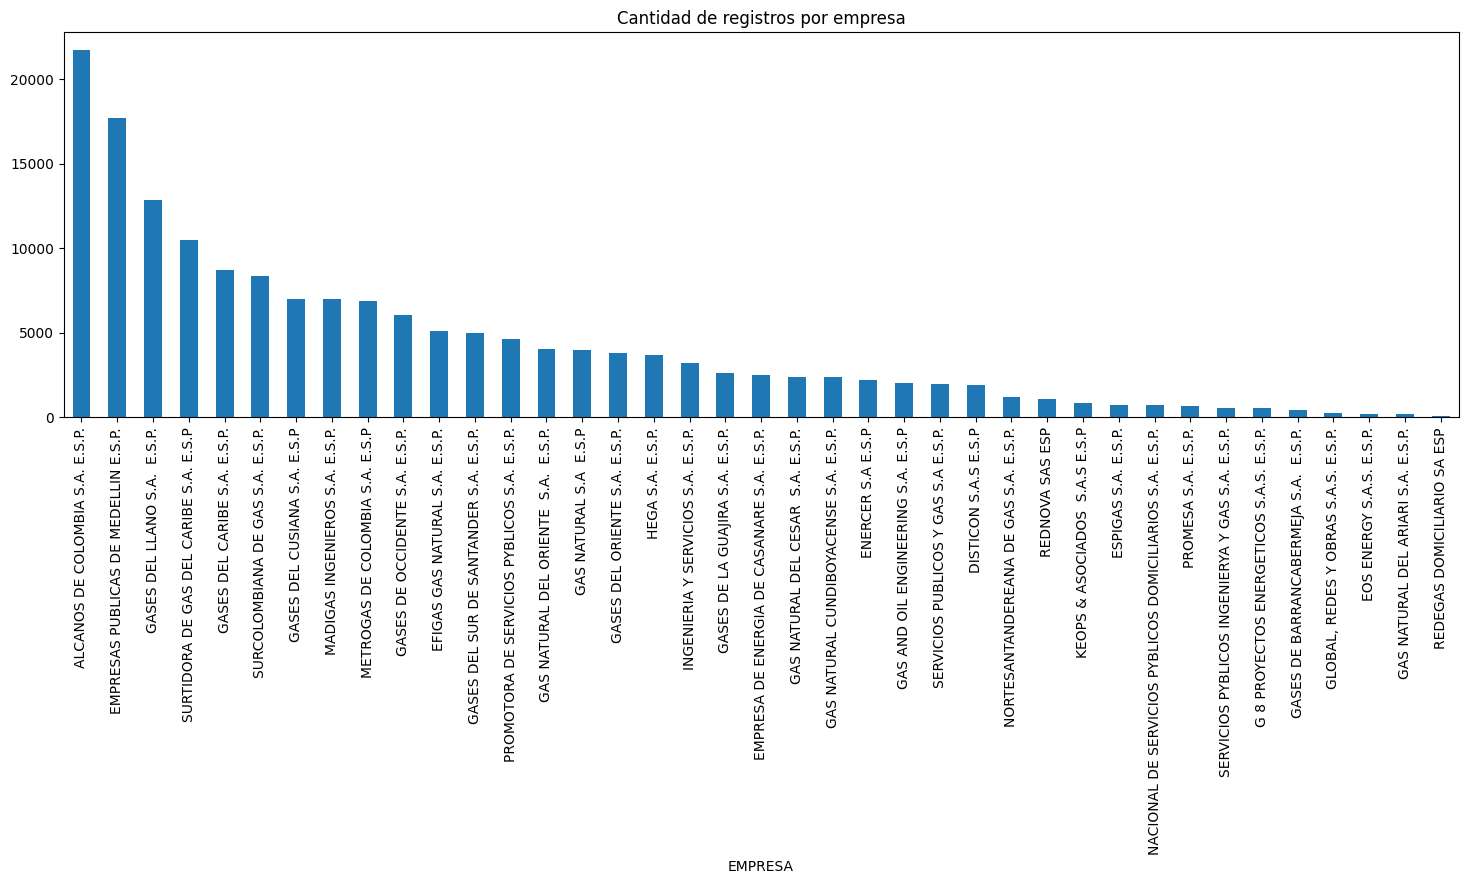

In [7]:
df["EMPRESA"].value_counts().plot.bar(figsize=(18,5), title="Cantidad de registros por empresa")
plt.show()

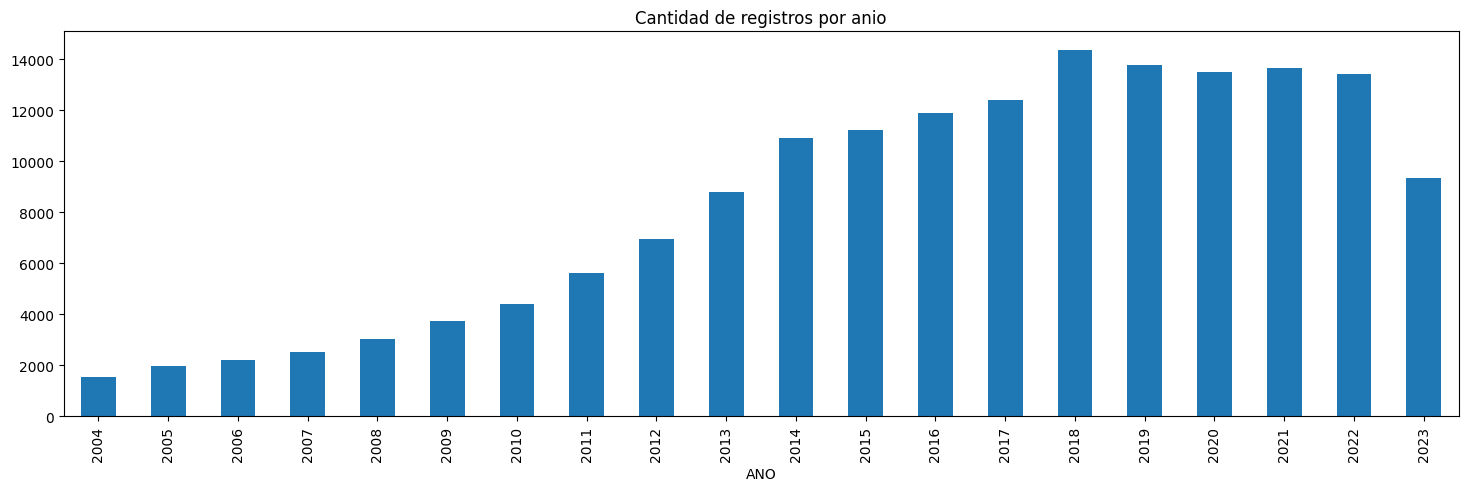

In [8]:
df["ANO"].value_counts().sort_index().plot.bar(figsize=(18,5), title="Cantidad de registros por anio")
plt.show()

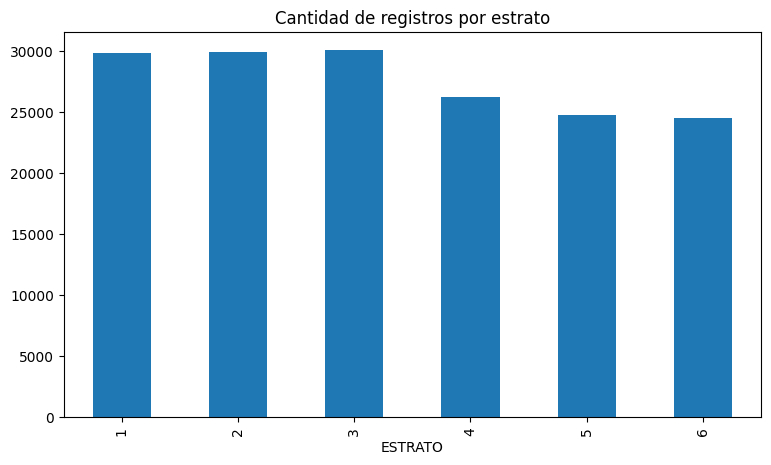

In [9]:
df["ESTRATO"].value_counts().sort_index().plot.bar(figsize=(9,5), title="Cantidad de registros por estrato")
plt.show()

### Analisis cuantitativo

In [10]:
df_numericas = df.loc[:, "CONEXION":"RANGO_21"].copy()

In [11]:
numeric_describe = df_numericas.describe()
numeric_describe.apply(lambda s: s.apply('{00:,.2f}'.format))

,CONEXION,REINSTALACION,RECONEXION,CARGO_FIJO,RANGO_0,RANGO_21
count,"165,360.00","165,360.00","165,360.00","165,360.00","165,360.00","165,360.00"
mean,"574,319.46","184,035.88","28,119.98","2,128.68","1,931.04","1,416.39"
std,"170,553.93","137,560.77","29,805.84","13,086.42","13,825.30","1,324.45"
min,0.00,0.00,0.00,"-1,009.71",0.00,0.00
25%,"489,125.00","85,263.00","20,660.00",0.00,861.82,671.51
50%,"550,327.00","156,385.00","27,171.00","2,266.61","1,379.00","1,390.98"
75%,"627,208.00","222,500.00","34,875.00","3,382.51","2,204.25","2,009.53"
max,"1,870,000.00","9,826,062.00","4,600,207.50","3,723,696.00","5,119,020.50","157,525.00"


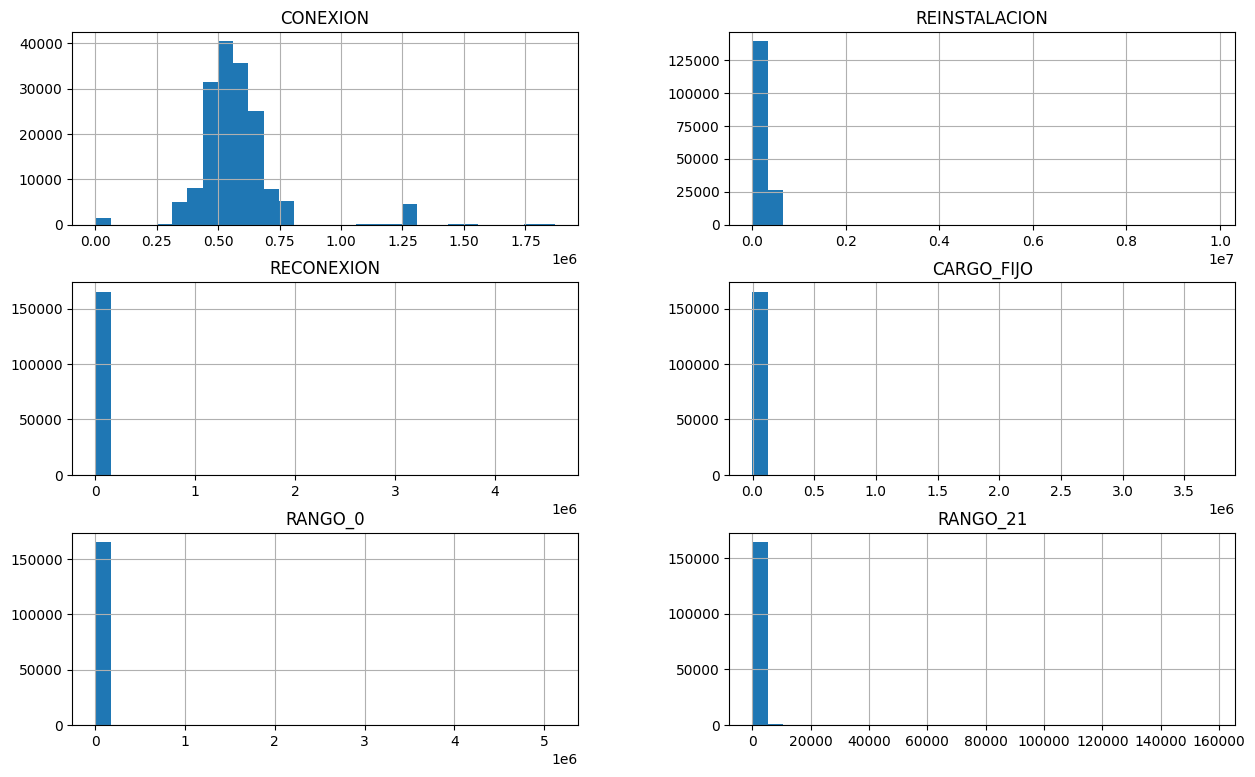

In [12]:
df_numericas.hist(figsize=(15,9), bins=30)
plt.show()

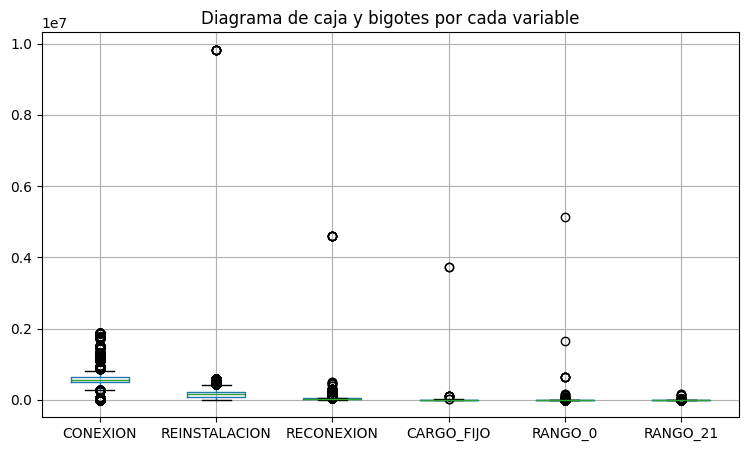

In [13]:
df_numericas.boxplot(figsize=(9,5))
plt.title('Diagrama de caja y bigotes por cada variable')
plt.show()

Segun lo analizado en los graficos anteriores, se puede notar que existe unos datos atipicos, para muchas de las variables, a continuacion se muestran los registros que tienen esos datos atipicos.

In [14]:
df.loc[lambda x: x["CARGO_FIJO"] > 0.2e7]

,ANO,MES,EMPRESA,MUNICIPIOS,NIT,ID MERCADO,ID_EMPRESA,ESTRATO,CONEXION,REINSTALACION,RECONEXION,CARGO_FIJO,RANGO_0,RANGO_21
99821,2016,4,"GLOBAL, REDES Y OBRAS S.A.S. E.S.P.",PACHO,9009227600,140,32215,6,565388.0,30000.0,96000.0,3723696.0,2437.29,0.0
99822,2016,4,"GLOBAL, REDES Y OBRAS S.A.S. E.S.P.",PACHO,9009227600,140,32215,5,565388.0,30000.0,96000.0,3723696.0,2437.29,0.0


In [15]:
df.loc[lambda x: x["REINSTALACION"] > 0.2e7]

,ANO,MES,EMPRESA,MUNICIPIOS,NIT,ID MERCADO,ID_EMPRESA,ESTRATO,CONEXION,REINSTALACION,RECONEXION,CARGO_FIJO,RANGO_0,RANGO_21
80030,2017,11,GAS NATURAL CUNDIBOYACENSE S.A. E.S.P.,BELEN - BRICENO - CALDAS - CERINZA - CHIQUINQU...,8300454728,169,2225,2,557571.0,9826062.0,4600207.5,0.0,647848.40,0.0
80032,2017,11,GAS NATURAL CUNDIBOYACENSE S.A. E.S.P.,BELEN - BRICENO - CALDAS - CERINZA - CHIQUINQU...,8300454728,169,2225,1,557571.0,9826062.0,4600207.5,0.0,5119020.50,0.0
80034,2017,11,GAS NATURAL CUNDIBOYACENSE S.A. E.S.P.,BELEN - BRICENO - CALDAS - CERINZA - CHIQUINQU...,8300454728,169,2225,6,557571.0,9826062.0,4600207.5,2632.0,1034.20,0.0
80037,2017,11,GAS NATURAL CUNDIBOYACENSE S.A. E.S.P.,BELEN - BRICENO - CALDAS - CERINZA - CHIQUINQU...,8300454728,169,2225,5,557571.0,9826062.0,4600207.5,2632.0,1034.20,0.0
80038,2017,11,GAS NATURAL CUNDIBOYACENSE S.A. E.S.P.,BELEN - BRICENO - CALDAS - CERINZA - CHIQUINQU...,8300454728,169,2225,4,557571.0,9826062.0,4600207.5,2193.0,861.83,0.0
80040,2017,11,GAS NATURAL CUNDIBOYACENSE S.A. E.S.P.,BELEN - BRICENO - CALDAS - CERINZA - CHIQUINQU...,8300454728,169,2225,3,557571.0,9826062.0,4600207.5,2193.0,861.83,0.0


In [16]:
df_max_ano = df[df["ANO"] == df["ANO"].max()].copy()

In [17]:
df_numericas = df_max_ano.loc[:, "CONEXION":"RANGO_21"].copy()

In [18]:
numeric_describe = df_numericas.describe()
numeric_describe.apply(lambda s: s.apply('{00:,.2f}'.format))

,CONEXION,REINSTALACION,RECONEXION,CARGO_FIJO,RANGO_0,RANGO_21
count,"9,356.00","9,356.00","9,356.00","9,356.00","9,356.00","9,356.00"
mean,"735,009.49","235,056.49","38,961.17","2,647.71","3,158.16","2,207.27"
std,"75,414.03","150,865.84","9,360.46","2,314.00","2,670.07","1,269.43"
min,0.00,"2,238.00",0.00,0.00,0.00,0.00
25%,"718,116.00","112,300.00","34,239.00",0.00,"1,532.00","1,763.57"
50%,"749,397.00","219,000.00","41,111.00","3,030.29","2,510.82","2,500.00"
75%,"807,975.00","252,518.00","43,042.00","4,317.46","3,464.00","3,081.35"
max,"809,667.00","581,453.00","219,000.00","8,263.92","14,908.20","5,135.64"


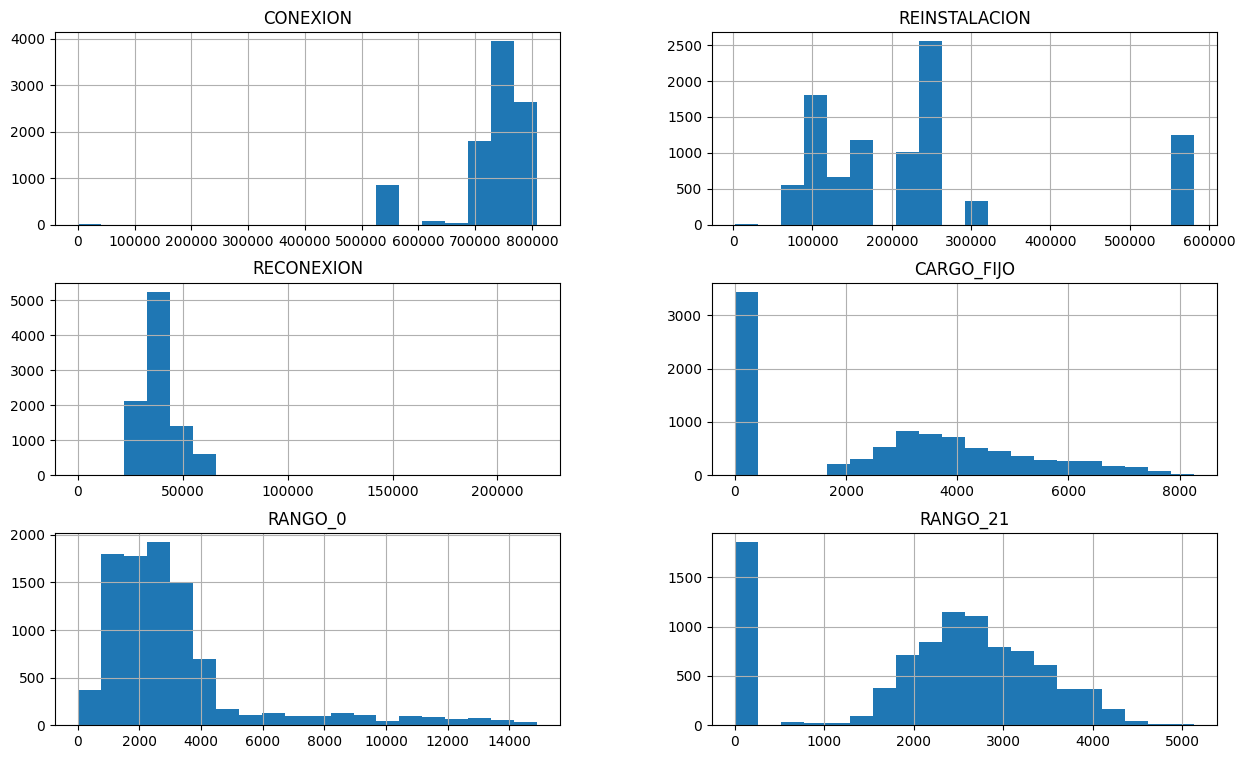

In [19]:
df_numericas.hist(figsize=(15,9), bins=20)
plt.show()

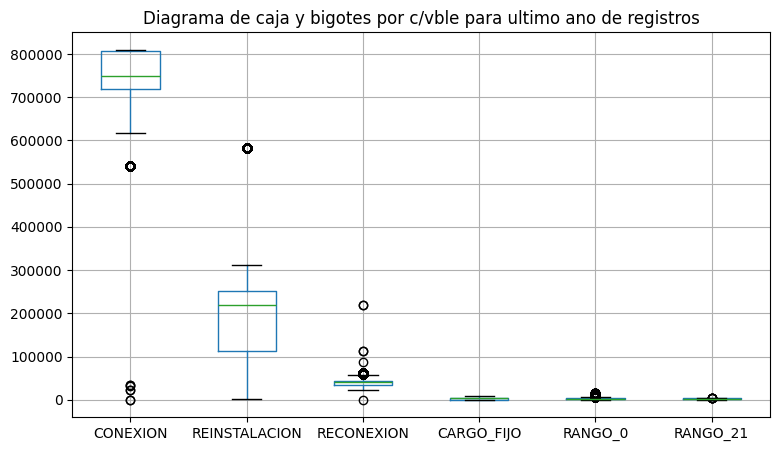

In [20]:
df_numericas.boxplot(figsize=(9,5))
plt.title('Diagrama de caja y bigotes por c/vble para ultimo ano de registros')
plt.show()

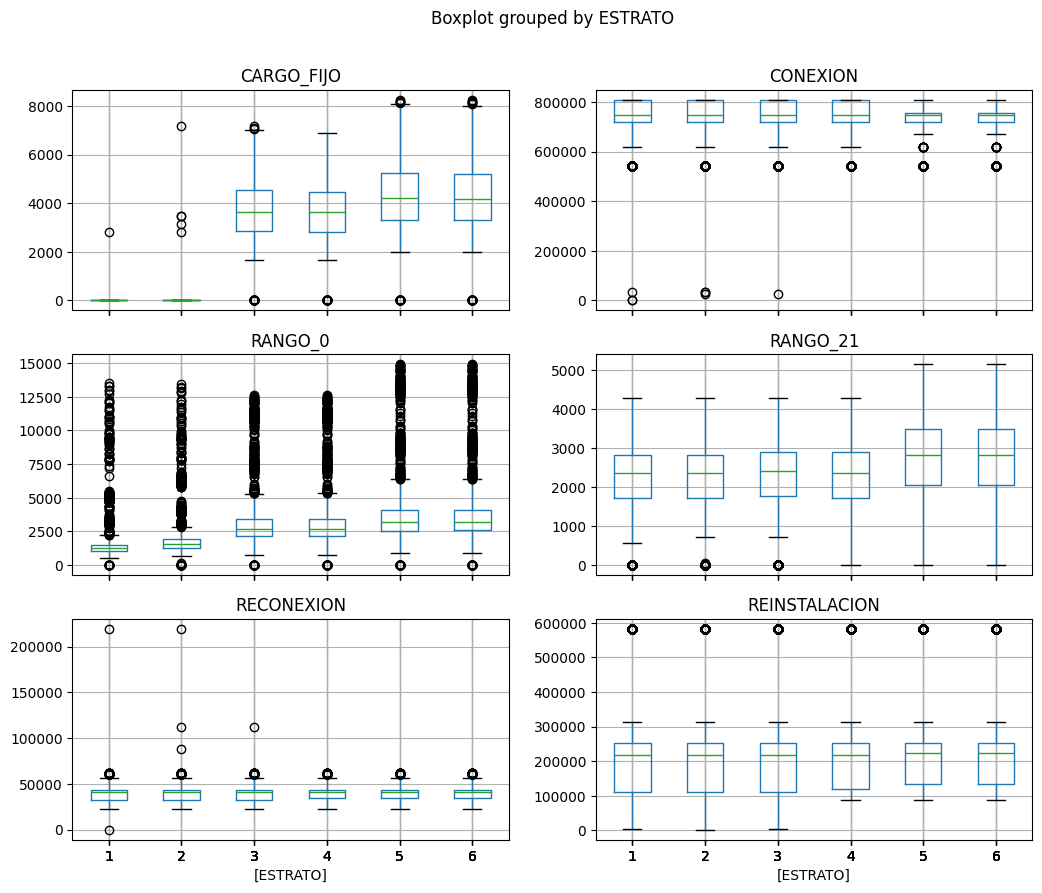

In [21]:
df_max_ano[["ESTRATO"] + df_numericas.columns.tolist()].boxplot(by = "ESTRATO",sharey=False, figsize=(12,10))
plt.show()

+ En las gráfica del boxplot para *CARGO_FIJO*, se puede ver que según el sistema de subsidios en Colombia, los estratos 3,4,5 subsidian los estrados 1 y 2, mostrando algunos outliers, que podrí ser caso de estudio en un futuro análisis. 
+ El costos de conexión, es igual para los estratos, no es prohibitivo para los estratos bajos, aunque presentan rango mayor de variación para los estratos inferiores a 4.
+ Según la columna *RANGO_0* de consumo inferior a 20 m^3, muestra que los estratos 1 y 2, asumen un menor valor que los estratos mayores. De las variables numéricas, es esta la que mas más valores atípicos presenta, esto puede deberse al mercado, que a su vez depende de la ubicación de geográfica.

In [22]:
df_max_ano['DIFF_RANGO'] = df_max_ano['RANGO_21'] - df_max_ano['RANGO_0']

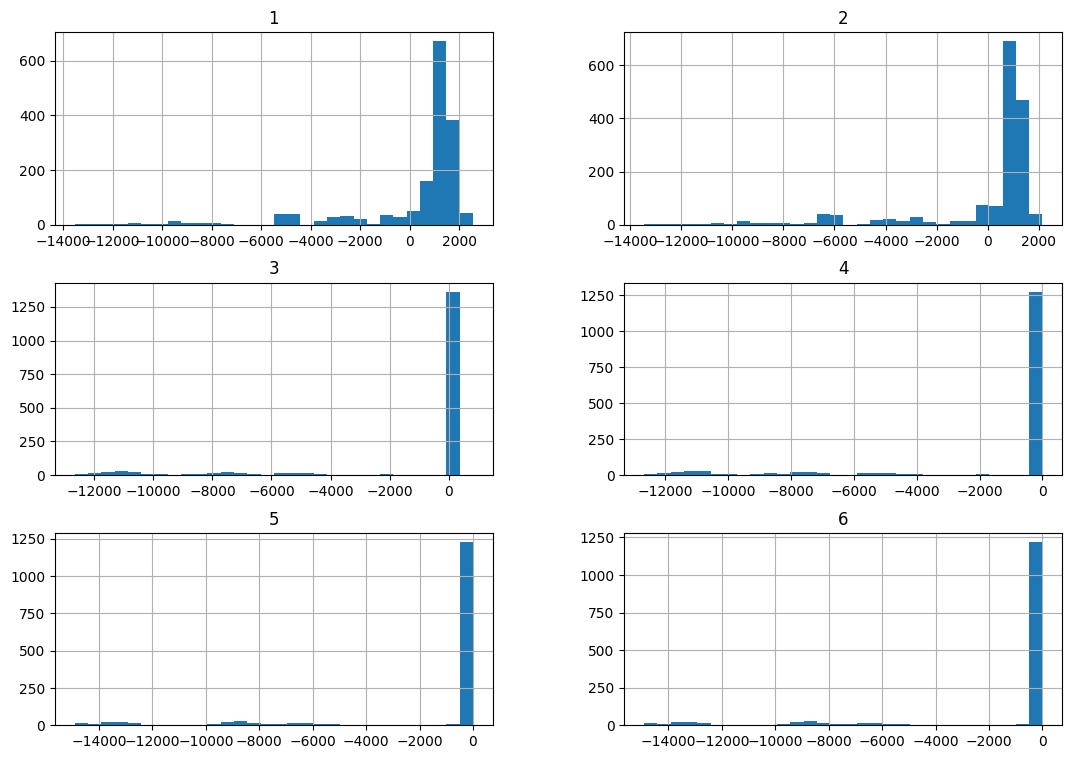

In [23]:
df_max_ano.pivot(columns="ESTRATO",values="DIFF_RANGO").hist(figsize=(13,9), bins=30)
plt.show()

+ Según el análisis anterior los estratos 1 y 2  presentan diferencias > 0, lo que puede indicar que el metro cúbico en el RANGO_21 es más caro que en el RANGO_0. Es el resultado directo del "Subsidio de Subsistencia", el Estado ayuda a pagar los primeros 20m^3, pero después de ese límite, el usuario debe pagar el costo real (que es más alto).
+ Los Estratos 4, 5 y 6 presentan diferencias <=  0,  esto parece ser una anomalía. Si la diferencia es cercana a 0, significa que el precio es plano (cuesta lo mismo el primer metro cúbico que el número 100). Si es negativa, significaría que el gas es más barato entre más consumes (un modelo regresivo o de "descuento por volumen").

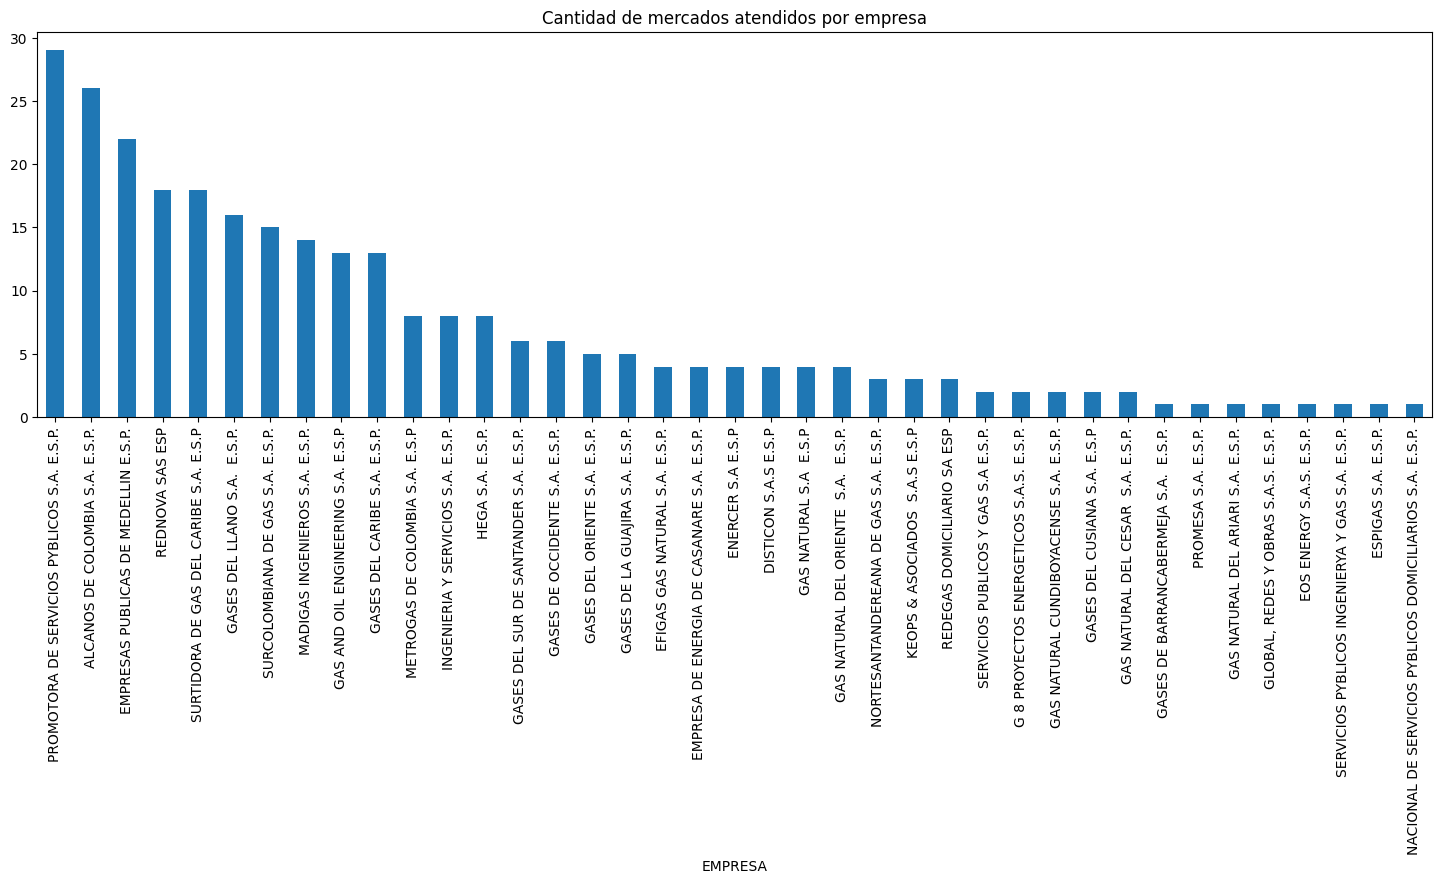

In [24]:
df.groupby(["EMPRESA"])["ID MERCADO"].nunique().sort_values(ascending=False).plot.bar(figsize=(18,5), title="Cantidad de mercados atendidos por empresa")
plt.show()

In [25]:
df["MUNICIPIOS_LISTA"] = df["MUNICIPIOS"].apply(lambda x: [i.strip() for i in x.split("-")])

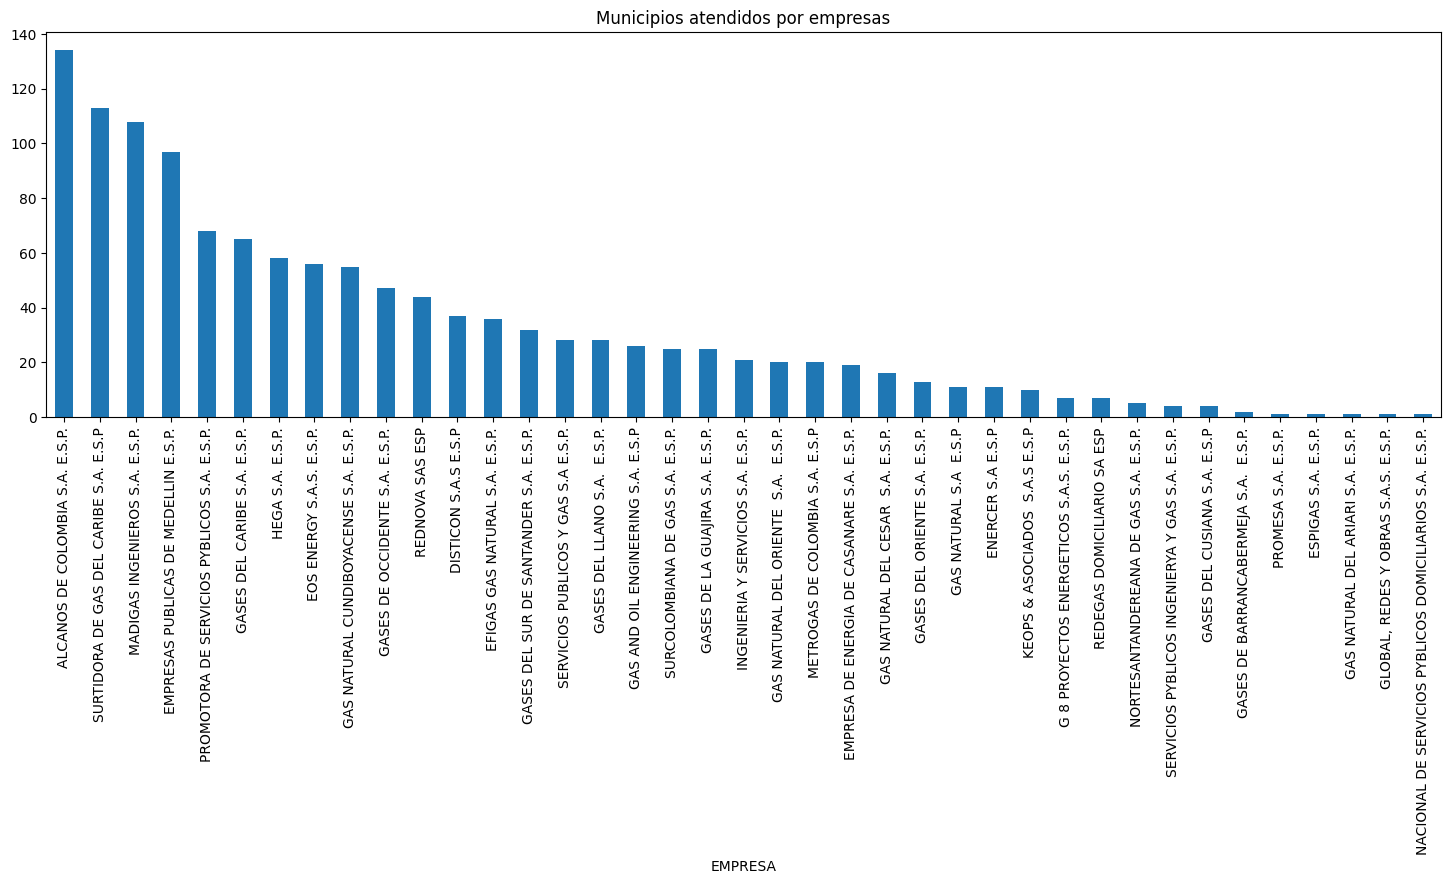

In [26]:
df.groupby('EMPRESA')['MUNICIPIOS_LISTA'].apply(lambda x: x.explode().nunique()).sort_values(ascending=False).plot.bar(title = "Municipios atendidos por empresas", figsize=(18,5))
plt.show()

In [27]:
df_empresa_estrato = df.value_counts(["EMPRESA", "ESTRATO"]).unstack()
df_empresa_estrato['Total'] = df_empresa_estrato.sum(axis=1)
df_empresa_estrato.sort_values('Total', ascending=False, inplace=True)
df_empresa_estrato.loc[:,[1,2,3,4,5,6]]

ESTRATO,1,2,3,4,5,6
EMPRESA,,,,,,
ALCANOS DE COLOMBIA S.A. E.S.P.,3618.0,3618.0,3618.0,3617.0,3617.0,3617.0
EMPRESAS PUBLICAS DE MEDELLIN E.S.P.,2952.0,2952.0,2952.0,2949.0,2949.0,2949.0
GASES DEL LLANO S.A. E.S.P.,2703.0,2706.0,2704.0,1582.0,1582.0,1582.0
SURTIDORA DE GAS DEL CARIBE S.A. E.S.P,1747.0,1747.0,1747.0,1747.0,1747.0,1747.0
GASES DEL CARIBE S.A. E.S.P.,1459.0,1459.0,1446.0,1447.0,1447.0,1447.0
SURCOLOMBIANA DE GAS S.A. E.S.P.,1394.0,1394.0,1394.0,1394.0,1394.0,1394.0
GASES DEL CUSIANA S.A. E.S.P,1188.0,1189.0,1186.0,1186.0,1138.0,1126.0
MADIGAS INGENIEROS S.A. E.S.P.,1809.0,1811.0,1809.0,775.0,422.0,355.0
METROGAS DE COLOMBIA S.A. E.S.P,1150.0,1150.0,1150.0,1150.0,1150.0,1150.0


De la tala anterior se destaca, que algunas empresas no hacen cobro, o no tienen mercado en los estratos 4,5,6. A continuacion se presenta el reoprte gráfico de ésta tabla.

<Axes: xlabel='EMPRESA'>

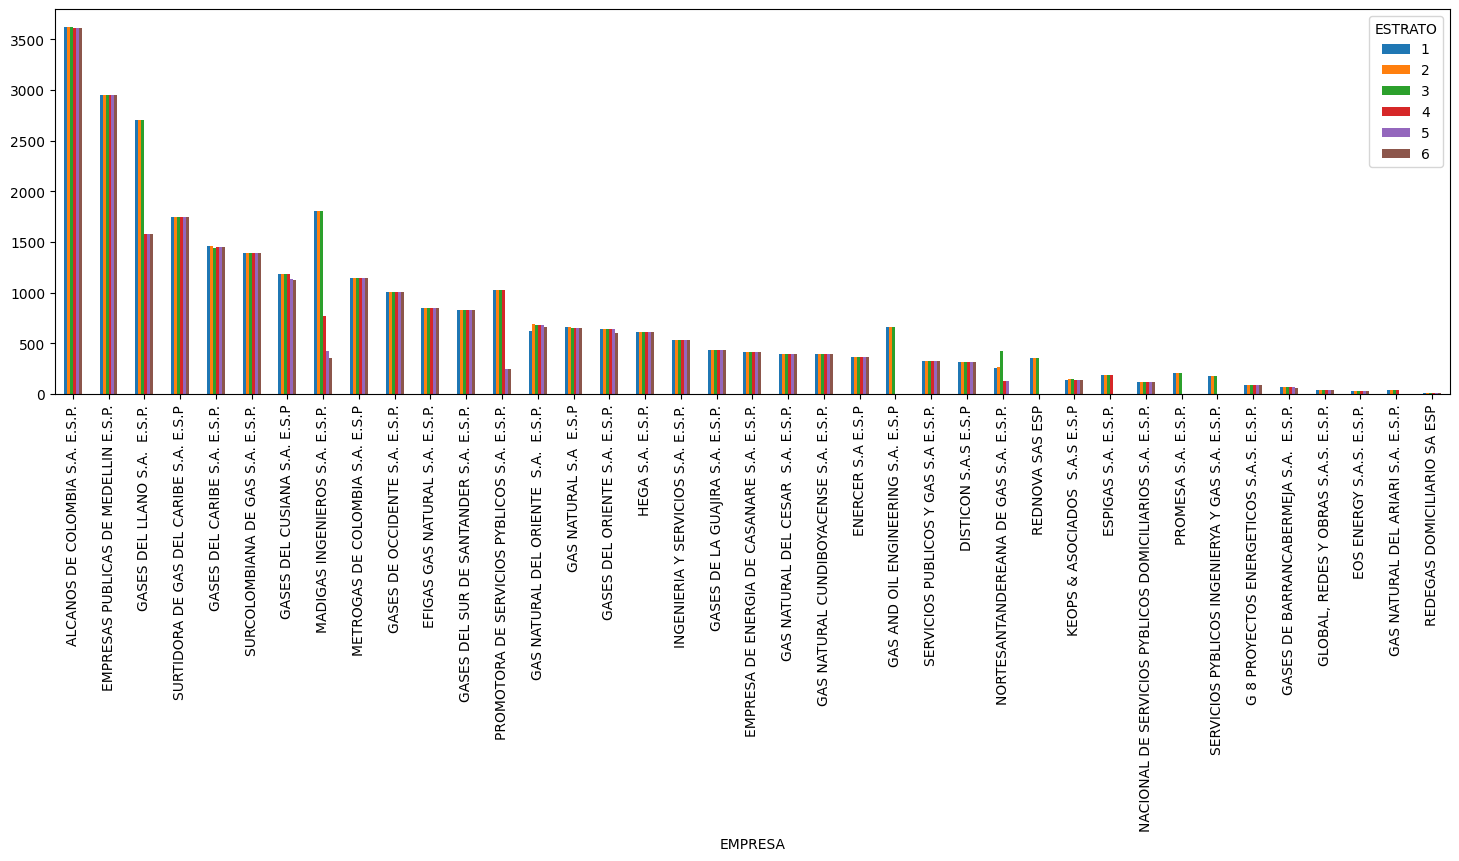

In [ ]:
df_empresa_estrato.loc[:,[1,2,3,4,5,6]].plot.bar(stacked=False, figsize=(18,5))
plt.show()

In [30]:
df[["ID MERCADO", "MUNICIPIOS"]].drop_duplicates().loc[lambda x: x["ID MERCADO"].isin([1265,1825])]

,ID MERCADO,MUNICIPIOS
295,1825,MONGUI - TOPAGA - GAMEZA - MONGUA
296,1265,CORRALES
297,1265,BUSBANZA


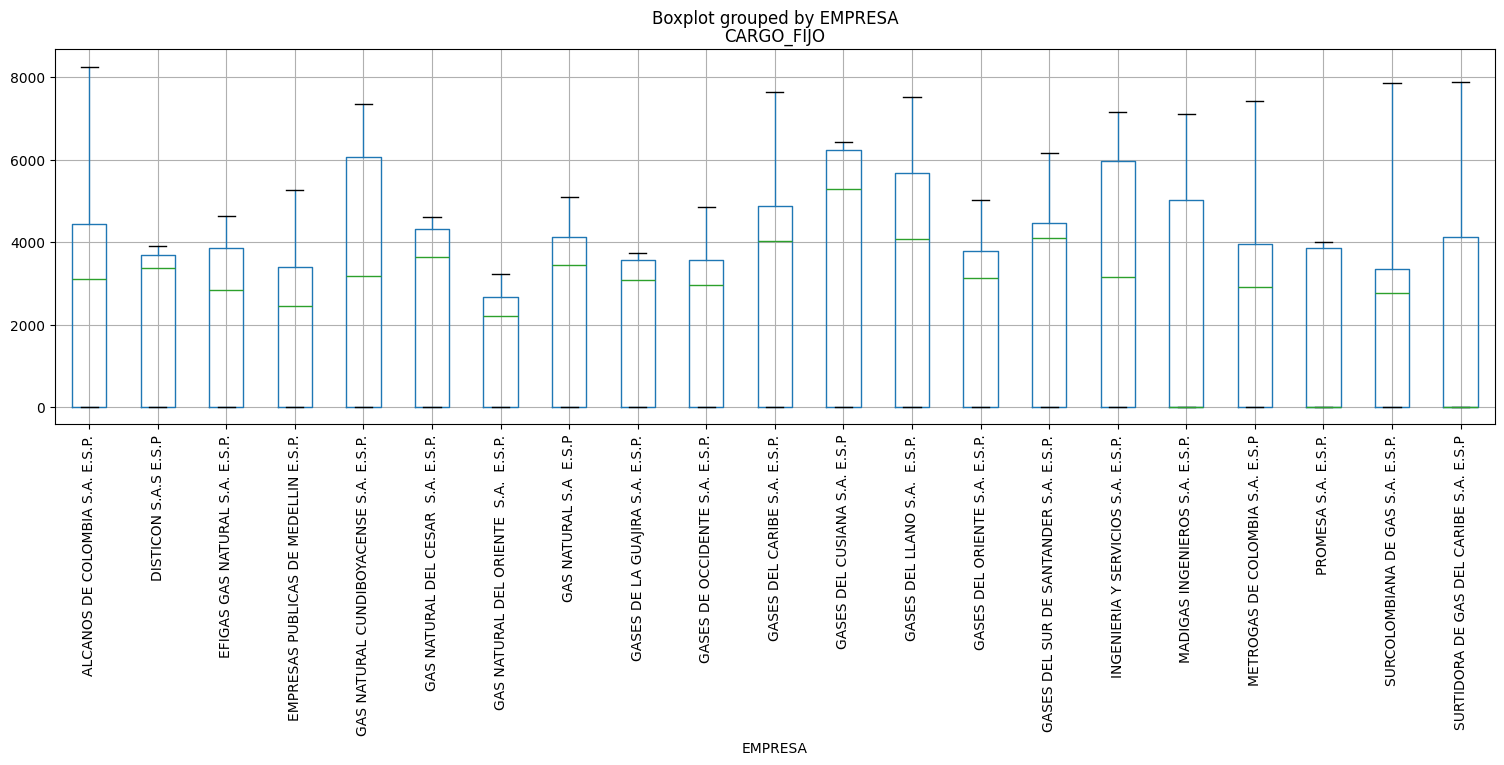

In [34]:
df_max_ano.boxplot(column=["CARGO_FIJO"], by="EMPRESA", figsize=(18,5))
plt.xticks(rotation=90)
plt.show()

De este último análisis se puede decir que niguna de las empresas para el año 2023, supera un cargo fijo de COP 8000. y que los precios, con algunas excepciones, de forma generalizada están alrededor de COP 2000 y 4000.